# SpinLab Getting Started Tutorial

Welcome to the SpinLab getting started tutorial.

This notebook introduces the basic workflow for loading and visualizing EPR data.

The tutorial is designed for new users and assumes minimal Python experience.

## Tutorial Goals

In this notebook we will:

- Load an example EPR dataset
- Inspect the data structure
- Plot the signal
- Perform basic processing
- Discuss common workflows

## About SpinLab

SpinLab is a Python package for EPR and magnetic resonance data processing.

It provides tools for:

- Data loading
- Signal processing
- Visualization
- Spectral analysis
- Workflow automation

## Loading Data

In the next section we will load an example dataset.

The example dataset is included in the repository under the `data/` directory.

In [ ]:
# Load example data here

## Inspecting the Dataset

Once the data is loaded, we can inspect:

- Dimensions
- Axes
- Metadata
- Signal values

In [2]:
# Inspect dataset here
path = '../data/specman_essem.d01'

import spinlab as sl
data = sl.load(path)
print(data)

values:
	1064 ndarray (complex128)
dims:
	['t']
coords:
	array([3.200e-08, 4.000e-08, 4.800e-08, ..., 8.520e-06, 8.528e-06,
       8.536e-06], shape=(1064,))
attrs:
	'general_version': '1.1'
	'general_demon': '3.5.8602'
	'general_name': '3pESEEM'
	'general_dconfig': 'CNIGM0114rev1.cfg'
	'general_pconfig': 'CNIGM0114rev1.cfp'
	+190 attrs


## Plotting the Signal

Visualization is one of the most important parts of EPR data analysis.

We will generate a simple plot of the signal.

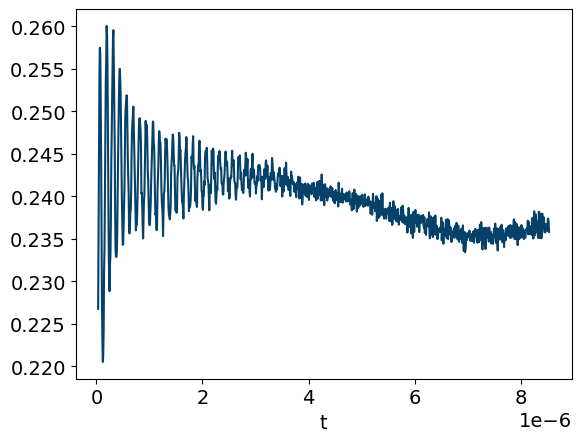

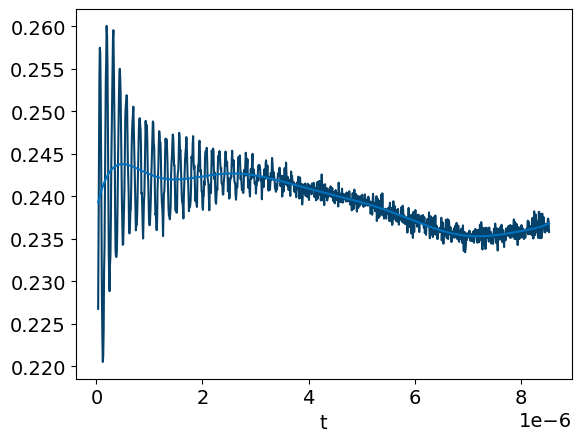

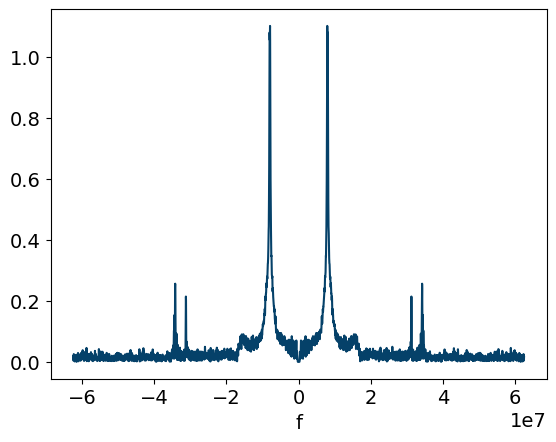

In [4]:
from matplotlib.pylab import plt
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.figure()
sl.plot(data.real)
# sl.plot(data.imag)

data_real = data.real

#data = sl.remove_background(data, dim = 't', deg = 9)

background = sl.background(data_real, dim = 't', deg = 9)


plt.figure()
sl.plot(data_real, label = 'data')
sl.plot(background, label = 'fit')
plt.show()

data_real -= background

data_ft = sl.fourier_transform(data_real, dim = 't', zero_fill_factor = 4, convert_to_ppm = False)

plt.figure()
sl.plot(data_ft.abs)
plt.show()

## Basic Processing

Typical processing operations may include:

- Phase correction
- Baseline correction
- Signal averaging
- Fourier transforms
- Normalization

In [ ]:
# Processing steps here

## Summary

In this notebook we introduced the basic SpinLab workflow.

Next tutorials will explore:

- Multi-dimensional datasets
- Echo processing
- Spectral fitting
- Advanced visualization
- Automated analysis pipelines